# Diffusion and Flow Matching: From First Principles to Code

This notebook is a companion to the *Diffusion and flow matching* tutorial. It walks through the key equations and turns each one into runnable, well-documented PyTorch code.

We will:

1. Build a **denoising diffusion model** from the ground up (forward process, score matching loss, $\varepsilon$- and $v$-parameterisations, and ancestral sampling).
2. Build a **flow matching model** (conditional flow matching loss, ODE-based generation).
3. Train both on a 2D toy distribution (a mixture of Gaussians arranged in a ring) so everything runs in a few minutes on CPU.
4. Visualise the learned generative process.

The math is summarised in markdown; the code is structured so the same `NoiseSchedule` and toy data utilities are shared between the diffusion and flow-matching halves.

---

**A note on the original tutorial's code.** The snippets in the LaTeX source were illustrative pseudocode, not standalone runnable code. In this notebook we have rewritten them with:

- Descriptive variable names (e.g. `noisy_sample` instead of `z_t`, `predicted_noise` instead of `pred`).
- Explicit type hints and docstrings.
- Tensor-shape comments at every non-obvious step.
- Clear separation between the noise schedule, the forward (diffusion) process, the loss, and the sampler.
- Bug fixes (the original snippets had a few small issues — e.g. `log` vs `torch.log`, `control_signals` vs `control_inputs`, `x.device` vs `z_1.device` — which we discuss in the relevant section).


## 0. Setup

We only need PyTorch, NumPy, and matplotlib. Everything trains on CPU in a few minutes.

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Callable, Literal

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

# Reproducibility
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")


Using device: mps


## 1. A toy 2D dataset

To keep training fast and the visualisations readable, we use a 2D mixture of Gaussians arranged on a ring. Each $\mathbf{x} \in \mathbb{R}^2$ is a sample from this "true" data distribution $p_d(\mathbf{x})$.

In the tutorial $\mathbf{x}$ stands for an image, video frame, audio segment, or protein. The *equations* are exactly the same — only the network architecture changes. Using 2D data lets us focus on the algorithm.

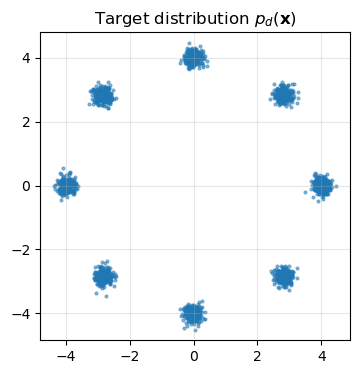

In [2]:
def sample_ring_of_gaussians(
    num_samples: int,
    num_modes: int = 8,
    radius: float = 4.0,
    mode_std: float = 0.15,
) -> Tensor:
    """Sample from an isotropic mixture of Gaussians arranged on a ring.

    Args:
        num_samples: Total number of points to draw.
        num_modes: Number of Gaussian components on the ring.
        radius: Distance from the origin to each component mean.
        mode_std: Standard deviation of each component.

    Returns:
        Tensor of shape (num_samples, 2).
    """
    mode_indices = torch.randint(0, num_modes, (num_samples,))
    angles = mode_indices.float() * (2 * math.pi / num_modes)
    means = torch.stack([radius * torch.cos(angles), radius * torch.sin(angles)], dim=-1)
    return means + mode_std * torch.randn(num_samples, 2)


# Quick visual sanity check
data_preview = sample_ring_of_gaussians(2000)
plt.figure(figsize=(4, 4))
plt.scatter(data_preview[:, 0], data_preview[:, 1], s=4, alpha=0.5)
plt.title("Target distribution $p_d(\\mathbf{x})$")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()


---

# Part A — Diffusion

## A.1 The forward (noising) process

For a clean data sample $\mathbf{x} \sim p_d(\mathbf{x})$ and a "time" $t \in [0, 1]$, define a noisy version

$$\mathbf{z}_t = \alpha_t\, \mathbf{x} + \sigma_t\, \boldsymbol{\varepsilon}, \qquad \boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}).$$

The two schedules $\alpha_t$ and $\sigma_t$ control how much signal vs. noise survives at time $t$. We use the **cosine schedule** $\alpha_t = \cos(\pi t / 2)$, $\sigma_t = \sin(\pi t / 2)$, which satisfies $\alpha_t^2 + \sigma_t^2 = 1$.

The **log signal-to-noise ratio** is

$$\lambda_t = \log \frac{\alpha_t^2}{\sigma_t^2} = -2 \log \tan(\pi t / 2).$$

It's monotonically decreasing in $t$, going from $+\infty$ (no noise) at $t=0$ to $-\infty$ (pure noise) at $t=1$. We clip it to a finite range for numerical stability.

From $\lambda_t$ we can recover $\alpha_t$ and $\sigma_t$ via the sigmoid:

$$\alpha_t^2 = \sigma\!\left(\lambda_t\right), \qquad \sigma_t^2 = \sigma\!\left(-\lambda_t\right).$$


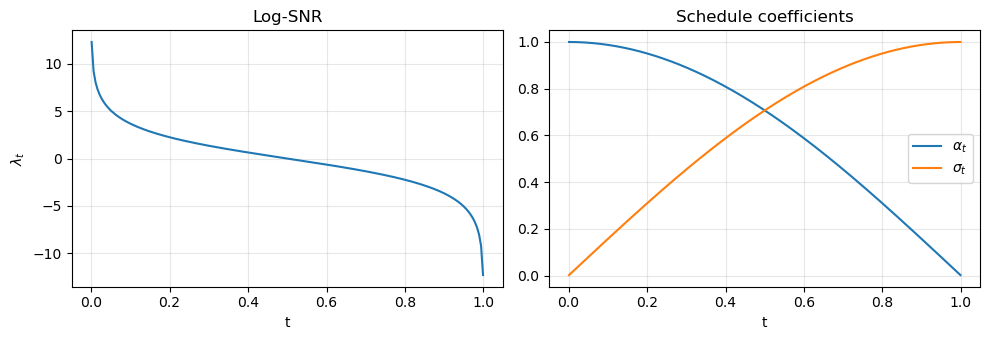

In [3]:
class CosineNoiseSchedule:
    """Cosine log-SNR schedule (Nichol & Dhariwal, 2021), with optional shift.

    Maps a time variable t in [0, 1] to a log signal-to-noise ratio lambda_t,
    and from there to the diffusion coefficients alpha_t and sigma_t.

    The optional `shift` argument implements the "shifted cosine" from the
    Simple Diffusion paper, which adapts the schedule to the spatial resolution
    of the data when training on images.
    """

    def __init__(
        self,
        log_snr_min: float = -15.0,
        log_snr_max: float = 15.0,
        shift: float = 0.0,
    ) -> None:
        self.log_snr_min = log_snr_min
        self.log_snr_max = log_snr_max
        self.shift = shift
        # Pre-compute the t-range bounds so log_snr is in [log_snr_min, log_snr_max].
        self._t_lo = math.atan(math.exp(-0.5 * log_snr_max))
        self._t_hi = math.atan(math.exp(-0.5 * log_snr_min))

    def log_snr(self, t: Tensor) -> Tensor:
        """Compute lambda_t = log(alpha_t^2 / sigma_t^2) for t in [0, 1].

        Args:
            t: Tensor of any shape with values in [0, 1].

        Returns:
            Tensor of the same shape, the (clipped) log-SNR.
        """
        if torch.any((t < 0) | (t > 1)):
            raise ValueError("t must be in [0, 1].")
        clipped_t = self._t_lo + t * (self._t_hi - self._t_lo)
        cosine_log_snr = -2.0 * torch.log(torch.tan(clipped_t))
        return cosine_log_snr + self.shift

    def alpha_sigma(self, log_snr_t: Tensor) -> tuple[Tensor, Tensor]:
        """Convert log-SNR to (alpha_t, sigma_t).

        Uses the numerically stable identities
            alpha_t^2 = sigmoid( log_snr_t ),
            sigma_t^2 = sigmoid(-log_snr_t).
        """
        alpha_t = torch.sqrt(torch.sigmoid(log_snr_t))
        sigma_t = torch.sqrt(torch.sigmoid(-log_snr_t))
        return alpha_t, sigma_t


# Visualise the schedule
schedule = CosineNoiseSchedule()
t_grid = torch.linspace(0.001, 0.999, 200)
log_snr_grid = schedule.log_snr(t_grid)
alpha_grid, sigma_grid = schedule.alpha_sigma(log_snr_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(t_grid, log_snr_grid)
axes[0].set_xlabel("t"); axes[0].set_ylabel(r"$\lambda_t$"); axes[0].set_title("Log-SNR")
axes[0].grid(alpha=0.3)
axes[1].plot(t_grid, alpha_grid, label=r"$\alpha_t$")
axes[1].plot(t_grid, sigma_grid, label=r"$\sigma_t$")
axes[1].set_xlabel("t"); axes[1].legend(); axes[1].set_title("Schedule coefficients")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Sampling from the forward process

Given a clean batch of $\mathbf{x}$'s and a time $t$, we draw $\mathbf{z}_t$ in one line. Notice that the original tutorial wrote

```python
def diffuse(self, x, alpha_t, sigma_t):
    eps_t = torch.randn_like(x)
    z_t = alpha_t * x + sigma_t * eps_t
    return z_t, eps_t
```

We rename `eps_t` to `noise` and `z_t` to `noisy_sample`, add a docstring, type hints, and remove the `self`-coupling so the function is reusable.

In [4]:
def add_noise(
    clean_sample: Tensor,
    alpha_t: Tensor,
    sigma_t: Tensor,
) -> tuple[Tensor, Tensor]:
    """Forward diffusion step: z_t = alpha_t * x + sigma_t * noise.

    Args:
        clean_sample: Clean data x, shape (batch, ...features).
        alpha_t: Per-sample signal coefficient, broadcastable to clean_sample.
        sigma_t: Per-sample noise coefficient, broadcastable to clean_sample.

    Returns:
        noisy_sample: z_t with the same shape as clean_sample.
        noise: The standard-normal noise that was added.
    """
    noise = torch.randn_like(clean_sample)
    noisy_sample = alpha_t * clean_sample + sigma_t * noise
    return noisy_sample, noise


## A.2 Score matching loss

We want a neural network to learn the score $\mathbf{s}_\theta(\mathbf{z}_t, \lambda_t) = \nabla_{\mathbf{z}} \log p_\theta(\mathbf{z}_t \mid \lambda_t)$. The denoised score-matching objective reduces (after some algebra in the tutorial) to predicting either the noise $\boldsymbol{\varepsilon}$ or the **velocity**

$$\mathbf{v}_t \;=\; \alpha_t\, \boldsymbol{\varepsilon} - \sigma_t\, \mathbf{x}.$$

Predicting $\mathbf{v}$ is more numerically stable across the schedule (Salimans & Ho, *Progressive Distillation*) because in both extremes $\sigma_t \to 0$ and $\alpha_t \to 0$ the target is well behaved. From a $\mathbf{v}$-prediction one can recover

$$\hat{\boldsymbol{\varepsilon}} = \sigma_t\, \mathbf{z}_t + \alpha_t\, \mathbf{v}_\theta, \qquad \hat{\mathbf{x}} = \alpha_t\, \mathbf{z}_t - \sigma_t\, \mathbf{v}_\theta.$$

The loss is then simply the MSE between the predicted noise and the true noise.

### Bug fix from the original snippet
The tutorial's loss code used `log` (undefined) instead of `torch.log` in the schedule, and indexed `x.device` from a `self` field — both small slips. The version below is self-contained and explicit.

In [5]:
Parameterisation = Literal["v", "eps"]


def diffusion_loss(
    score_network: nn.Module,
    clean_batch: Tensor,
    schedule: CosineNoiseSchedule,
    parameterisation: Parameterisation = "v",
    condition: Tensor | None = None,
) -> Tensor:
    """Denoising score-matching loss for a diffusion model.

    For each sample in the batch we draw an independent time t ~ U[0, 1],
    add the corresponding noise, ask the network for either the noise or
    the velocity, convert to a noise prediction, and compute MSE against
    the true noise.

    Args:
        score_network: A module mapping (noisy_sample, log_snr_t, condition) ->
            either predicted noise (parameterisation="eps") or predicted
            velocity (parameterisation="v"), with the same shape as
            noisy_sample.
        clean_batch: Real data x, shape (batch, ...features).
        schedule: Noise schedule providing log_snr and alpha_sigma.
        parameterisation: Which target the network outputs.
        condition: Optional conditioning info passed to the network.

    Returns:
        Scalar MSE loss.
    """
    batch_size = clean_batch.shape[0]
    device = clean_batch.device

    # Sample one t per example, then look up alpha_t, sigma_t, lambda_t.
    t = torch.rand(batch_size, device=device)
    log_snr_t = schedule.log_snr(t)
    alpha_t, sigma_t = schedule.alpha_sigma(log_snr_t)

    # Reshape the schedule scalars so they broadcast over the feature dims.
    feature_shape = (-1,) + (1,) * (clean_batch.ndim - 1)
    alpha_t = alpha_t.view(feature_shape)
    sigma_t = sigma_t.view(feature_shape)

    # Forward noising.
    noisy_sample, true_noise = add_noise(clean_batch, alpha_t, sigma_t)

    # Network forward pass.
    network_output = score_network(noisy_sample, log_snr_t, condition)

    # Convert whatever the network predicts into a noise prediction so we can
    # compare against `true_noise` with the same loss in both parameterisations.
    if parameterisation == "v":
        predicted_noise = sigma_t * noisy_sample + alpha_t * network_output
    elif parameterisation == "eps":
        predicted_noise = network_output
    else:
        raise ValueError(f"Unknown parameterisation: {parameterisation!r}")

    return F.mse_loss(predicted_noise, true_noise)


## A.3 Ancestral sampling (inference)

After training, we generate samples by reversing the diffusion. The tutorial derives a Gaussian transition $q(\mathbf{z}_t \mid \mathbf{z}_{t+1}, \mathbf{x})$ which, after substituting our learned $\hat{\mathbf{x}}_\theta$ for $\mathbf{x}$, becomes

$$q(\mathbf{z}_s \mid \mathbf{z}_t) = \mathcal{N}\!\left( \mathbf{z}_s;\; \alpha_s \!\left[\frac{1-c}{\alpha_t} \mathbf{z}_t + c\, \hat{\mathbf{x}}_\theta\right],\; c\, \sigma_s^2 \mathbf{I} \right),$$

with $c = 1 - e^{\lambda_t - \lambda_s}$ (where $s$ is one step *less noisy* than $t$). We start from $\mathbf{z}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and iterate.

### Bug fix
The original snippet referenced `control_signals` (undefined) in one place and `control_inputs` elsewhere; we just use one name.

In [6]:
@torch.no_grad()
def ancestral_sampling_step(
    noisy_sample: Tensor,
    network_output: Tensor,
    log_snr_t: Tensor,
    log_snr_s: Tensor,
    parameterisation: Parameterisation,
    clip_to: tuple[float, float] | None = (-1.0, 1.0),
) -> tuple[Tensor, Tensor]:
    """One reverse step of ancestral sampling, from noise level t down to s < t.

    Args:
        noisy_sample: Current iterate z_t, shape (batch, ...features).
        network_output: The network's prediction at (z_t, log_snr_t).
        log_snr_t: Current (more noisy) log-SNR, scalar tensor.
        log_snr_s: Target (less noisy) log-SNR, scalar tensor.
        parameterisation: Whether the network predicts "v" or "eps".
        clip_to: Optional clamp range for the predicted clean sample, useful
            when data is normalised to [-1, 1]. Set to None to disable.

    Returns:
        posterior_mean: The mean of the reverse Gaussian.
        posterior_variance: The (scalar) variance of the reverse Gaussian.
    """
    # -expm1(x) = 1 - exp(x); positive when x < 0 (i.e. log_snr_t < log_snr_s).
    c = -torch.expm1(log_snr_t - log_snr_s)

    alpha_t = torch.sqrt(torch.sigmoid(log_snr_t))
    alpha_s = torch.sqrt(torch.sigmoid(log_snr_s))
    sigma_t = torch.sqrt(torch.sigmoid(-log_snr_t))
    sigma_s = torch.sqrt(torch.sigmoid(-log_snr_s))

    # Decode the network output into a prediction of the clean sample x.
    if parameterisation == "v":
        predicted_clean = alpha_t * noisy_sample - sigma_t * network_output
    elif parameterisation == "eps":
        predicted_clean = (noisy_sample - sigma_t * network_output) / alpha_t
    else:
        raise ValueError(f"Unknown parameterisation: {parameterisation!r}")

    if clip_to is not None:
        predicted_clean = predicted_clean.clamp(*clip_to)

    posterior_mean = alpha_s * (
        noisy_sample * (1.0 - c) / alpha_t + c * predicted_clean
    )
    posterior_variance = (sigma_s ** 2) * c
    return posterior_mean, posterior_variance


@torch.no_grad()
def generate_samples(
    score_network: nn.Module,
    schedule: CosineNoiseSchedule,
    sample_shape: tuple[int, ...],
    num_steps: int = 100,
    parameterisation: Parameterisation = "v",
    condition: Tensor | None = None,
    clip_to: tuple[float, float] | None = None,
    device: torch.device = DEVICE,
) -> Tensor:
    """Generate a batch of samples by running ancestral sampling end-to-end.

    Args:
        score_network: Trained denoising network.
        schedule: Noise schedule.
        sample_shape: Shape of the batch to generate, e.g. (1024, 2).
        num_steps: Number of denoising steps. More steps => more accurate.
        parameterisation: Which target the network outputs.
        condition: Optional conditioning info.
        clip_to: Optional clamp on intermediate clean predictions.
        device: Device to draw the initial noise on.

    Returns:
        Tensor of shape sample_shape, drawn (approximately) from p_d.
    """
    # Initialise from pure Gaussian noise.
    sample = torch.randn(sample_shape, device=device)

    # We integrate from t=1 (pure noise) down to t=0 (clean data) on a uniform grid.
    for step in reversed(range(1, num_steps + 1)):
        t_now = torch.tensor(step / num_steps, device=device)
        t_next = torch.tensor((step - 1) / num_steps, device=device)

        log_snr_t = schedule.log_snr(t_now)
        log_snr_s = schedule.log_snr(t_next)

        # The network expects a per-sample log-SNR; broadcast scalar to batch.
        log_snr_t_batched = log_snr_t.expand(sample.shape[0])
        network_output = score_network(sample, log_snr_t_batched, condition)

        mean, variance = ancestral_sampling_step(
            noisy_sample=sample,
            network_output=network_output,
            log_snr_t=log_snr_t,
            log_snr_s=log_snr_s,
            parameterisation=parameterisation,
            clip_to=clip_to,
        )

        if step > 1:
            # Stochastic step: add noise scaled by sqrt(variance).
            sample = mean + torch.randn_like(mean) * torch.sqrt(variance)
        else:
            # Last step: just take the mean (deterministic) to avoid noisy outputs.
            sample = mean

    return sample


## A.4 A small MLP score network

For 2D data we just use an MLP. The same training/inference code would work for images by swapping in a U-Net or a transformer. The network takes `(noisy_sample, log_snr, condition)` and returns a tensor of the same shape as `noisy_sample`.

We embed the (continuous) log-SNR using random Fourier features so the network can sharply distinguish nearby noise levels.

In [7]:
class FourierFeatureEmbedding(nn.Module):
    """Random Fourier features for embedding a continuous scalar (e.g. log-SNR).

    Output is [sin(2*pi*x*W), cos(2*pi*x*W)] where W is a fixed random vector.
    """

    def __init__(self, num_frequencies: int = 64, scale: float = 16.0) -> None:
        super().__init__()
        # Buffer (not a Parameter): not trained, but moves with .to(device).
        self.register_buffer("frequencies", torch.randn(num_frequencies) * scale)

    def forward(self, scalar_input: Tensor) -> Tensor:
        # scalar_input has shape (batch,); produce (batch, 2*num_frequencies).
        projected = scalar_input[:, None] * self.frequencies[None, :] * 2 * math.pi
        return torch.cat([projected.sin(), projected.cos()], dim=-1)


class ScoreMLP(nn.Module):
    """A small MLP that maps (noisy_sample, log_snr, condition) -> prediction.

    The condition is optional; when None, the model is unconditional.
    """

    def __init__(
        self,
        data_dim: int = 2,
        hidden_dim: int = 256,
        num_layers: int = 4,
        time_embedding_dim: int = 64,
        condition_dim: int = 0,
    ) -> None:
        super().__init__()
        self.condition_dim = condition_dim

        self.time_embedding = FourierFeatureEmbedding(time_embedding_dim)
        time_features_dim = 2 * time_embedding_dim

        input_dim = data_dim + time_features_dim + condition_dim
        layers: list[nn.Module] = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, data_dim))
        self.network = nn.Sequential(*layers)

    def forward(
        self,
        noisy_sample: Tensor,
        log_snr_t: Tensor,
        condition: Tensor | None = None,
    ) -> Tensor:
        time_features = self.time_embedding(log_snr_t)
        components: list[Tensor] = [noisy_sample, time_features]
        if self.condition_dim > 0:
            assert condition is not None, "condition_dim > 0 but condition was None"
            components.append(condition)
        return self.network(torch.cat(components, dim=-1))


## A.5 Training the diffusion model

A few thousand steps of Adam on batches of toy data is enough to learn the ring.

In [8]:
def train_diffusion_model(
    score_network: nn.Module,
    schedule: CosineNoiseSchedule,
    *,
    num_training_steps: int = 5_000,
    batch_size: int = 512,
    learning_rate: float = 1e-3,
    parameterisation: Parameterisation = "v",
    log_every: int = 500,
) -> list[float]:
    """Train `score_network` by minimising the diffusion loss on the toy ring."""
    optimizer = torch.optim.Adam(score_network.parameters(), lr=learning_rate)
    loss_history: list[float] = []

    score_network.train()
    for step in range(num_training_steps):
        clean_batch = sample_ring_of_gaussians(batch_size).to(DEVICE)

        loss = diffusion_loss(
            score_network=score_network,
            clean_batch=clean_batch,
            schedule=schedule,
            parameterisation=parameterisation,
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        if (step + 1) % log_every == 0:
            recent = sum(loss_history[-log_every:]) / log_every
            print(f"  step {step + 1:5d}/{num_training_steps} | loss {recent:.4f}")

    return loss_history


schedule = CosineNoiseSchedule()
diffusion_network = ScoreMLP(data_dim=2).to(DEVICE)

print("Training diffusion model (v-parameterisation):")
diffusion_loss_history = train_diffusion_model(
    score_network=diffusion_network,
    schedule=schedule,
    num_training_steps=5_000,
    parameterisation="v",
)


Training diffusion model (v-parameterisation):
  step   500/5000 | loss 0.6776
  step  1000/5000 | loss 0.4576
  step  1500/5000 | loss 0.4399
  step  2000/5000 | loss 0.4325
  step  2500/5000 | loss 0.4237
  step  3000/5000 | loss 0.4179
  step  3500/5000 | loss 0.4132
  step  4000/5000 | loss 0.4058
  step  4500/5000 | loss 0.4039
  step  5000/5000 | loss 0.4040


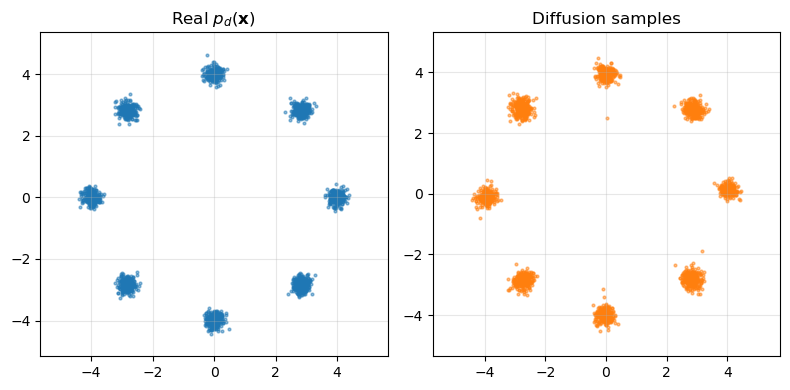

In [9]:
# Sample from the trained model and compare to the true ring.
diffusion_network.eval()
generated_samples = generate_samples(
    score_network=diffusion_network,
    schedule=schedule,
    sample_shape=(2_000, 2),
    num_steps=100,
    parameterisation="v",
).cpu()

real_samples = sample_ring_of_gaussians(2_000)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(real_samples[:, 0], real_samples[:, 1], s=4, alpha=0.5)
axes[0].set_title("Real $p_d(\\mathbf{x})$"); axes[0].axis("equal"); axes[0].grid(alpha=0.3)
axes[1].scatter(generated_samples[:, 0], generated_samples[:, 1], s=4, alpha=0.5, color="C1")
axes[1].set_title("Diffusion samples"); axes[1].axis("equal"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


---

# Part B — Flow matching

## B.1 The key insight

Flow matching shows that the **same marginal distribution** $p_t(\mathbf{z})$ produced by the forward diffusion $\mathbf{z}_t = \alpha_t \mathbf{x} + \sigma_t \boldsymbol{\varepsilon}$ can also be produced by a **deterministic ODE**

$$\frac{d \mathbf{z}(t)}{dt} = \mathbf{v}(\mathbf{z}, t),$$

with velocity field

$$\mathbf{v}(\mathbf{z}, t) = \dot{\alpha}_t \, \mathbb{E}[\mathbf{x} \mid \mathbf{z}_t = \mathbf{z}] + \dot{\sigma}_t \, \mathbb{E}[\boldsymbol{\varepsilon} \mid \mathbf{z}_t = \mathbf{z}].$$

So once we have $\mathbf{v}_\theta$, generation is *just running an ODE solver* — no Gaussian transitions needed. The simplest schedule, used in **conditional flow matching (CFM)** / **rectified flow**, is the linear one:

$$\alpha_t = t, \qquad \sigma_t = 1 - (1 - \sigma_{\min}) t,$$

with $\mathbf{x} = \mathbf{z}_1$ (data) and $\boldsymbol{\varepsilon} = \mathbf{z}_0$ (noise). The interpolant is

$$\boldsymbol{\psi}_t(\mathbf{z}_0, \mathbf{z}_1) = (1 - (1 - \sigma_{\min}) t) \mathbf{z}_0 + t \mathbf{z}_1,$$

and the loss is

$$\mathcal{L}(\theta) \;=\; \mathbb{E}_{t,\, \mathbf{z}_0,\, \mathbf{z}_1} \left\| \mathbf{v}_\theta\!\bigl(\boldsymbol{\psi}_t(\mathbf{z}_0, \mathbf{z}_1), t\bigr) - \bigl(\mathbf{z}_1 - (1 - \sigma_{\min}) \mathbf{z}_0\bigr) \right\|^2.$$

> **Direction reversal warning.** In the diffusion half $t=0$ meant clean data and $t=1$ meant pure noise. In the CFM literature the convention is flipped: $t=0$ is noise, $t=1$ is data. We follow CFM here for compatibility with most flow-matching code.

### Bug fix from the original snippet
The reference `OTFlowMatching.loss` referenced `x_1.device` in one line where it meant `z_1.device` — a typo that would crash. Fixed below.

In [10]:
class OptimalTransportFlowMatching:
    """Conditional Flow Matching with the linear / OT-style interpolant.

    `psi_t(z_0, z_1, t) = (1 - (1 - sigma_min) * t) * z_0 + t * z_1`

    so the target velocity along this straight-line path is the constant
    direction `z_1 - (1 - sigma_min) * z_0`.
    """

    def __init__(self, sigma_min: float = 1e-3, time_eps: float = 1e-5) -> None:
        self.sigma_min = sigma_min
        self.time_eps = time_eps

    def interpolant(self, noise: Tensor, data: Tensor, t: Tensor) -> Tensor:
        """Compute psi_t(noise, data) on the straight line between them."""
        return (1.0 - (1.0 - self.sigma_min) * t) * noise + t * data

    def target_velocity(self, noise: Tensor, data: Tensor) -> Tensor:
        """The constant-along-the-path target velocity."""
        return data - (1.0 - self.sigma_min) * noise

    def loss(
        self,
        velocity_network: nn.Module,
        data_batch: Tensor,
    ) -> Tensor:
        """Conditional flow matching loss.

        Uses *low-discrepancy* time sampling within the batch (one uniform t,
        offset by k/B) to reduce variance, as in the original FM paper.
        """
        batch_size = data_batch.shape[0]
        device = data_batch.device

        # Stratified t in [0, 1 - eps].
        base_t = torch.rand(1, device=device)
        offsets = torch.arange(batch_size, device=device) / batch_size
        t = (base_t + offsets) % (1.0 - self.time_eps)
        # Broadcast t over the feature dims.
        feature_shape = (-1,) + (1,) * (data_batch.ndim - 1)
        t = t.view(feature_shape)

        noise = torch.randn_like(data_batch)
        interpolated = self.interpolant(noise, data_batch, t)
        target = self.target_velocity(noise, data_batch)

        # The network expects t as a 1-D tensor of length batch_size.
        predicted = velocity_network(interpolated, t.view(batch_size), condition=None)
        return F.mse_loss(predicted, target)


## B.2 ODE-based generation

Inference is just an ODE solve. We implement a minimal RK4 integrator so the notebook has no extra dependencies — in practice you'd reach for `torchdiffeq` or `zuko.odeint`.

To **encode** (data → noise) we integrate from $t=1$ to $t=0$. To **decode** (noise → data) we integrate the other way.

In [11]:
def runge_kutta_4_step(
    velocity_fn: Callable[[Tensor, Tensor], Tensor],
    state: Tensor,
    t: Tensor,
    dt: Tensor,
) -> Tensor:
    """One classic RK4 step for state' = velocity_fn(state, t).

    Args:
        velocity_fn: Function (state, t_scalar) -> velocity, same shape as state.
        state: Current state, any shape.
        t: Current time, scalar tensor.
        dt: Step size, scalar tensor (positive for forward, negative for reverse).

    Returns:
        Next state at time t + dt.
    """
    k1 = velocity_fn(state, t)
    k2 = velocity_fn(state + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = velocity_fn(state + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = velocity_fn(state + dt * k3, t + dt)
    return state + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


class ConditionalVelocityField(nn.Module):
    """Wraps a `ScoreMLP`-style network as a velocity field for an ODE solver,
    and provides convenient encode / decode methods.
    """

    def __init__(self, network: nn.Module) -> None:
        super().__init__()
        self.network = network

    def forward(
        self,
        state: Tensor,
        t: Tensor,
        condition: Tensor | None = None,
    ) -> Tensor:
        return self.network(state, t, condition)

    def _broadcast_t(self, state: Tensor, t_scalar: Tensor) -> Tensor:
        return t_scalar.expand(state.shape[0])

    @torch.no_grad()
    def integrate(
        self,
        initial_state: Tensor,
        t_start: float,
        t_end: float,
        num_steps: int = 100,
    ) -> Tensor:
        """Integrate the ODE from t_start to t_end using RK4."""
        t = torch.tensor(t_start, device=initial_state.device, dtype=initial_state.dtype)
        dt = torch.tensor(
            (t_end - t_start) / num_steps,
            device=initial_state.device,
            dtype=initial_state.dtype,
        )

        def velocity_at(state: Tensor, t_scalar: Tensor) -> Tensor:
            return self(state, self._broadcast_t(state, t_scalar))

        state = initial_state
        for _ in range(num_steps):
            state = runge_kutta_4_step(velocity_at, state, t, dt)
            t = t + dt
        return state

    @torch.no_grad()
    def decode(self, noise: Tensor, num_steps: int = 100) -> Tensor:
        """Map noise (t=0) to data (t=1)."""
        return self.integrate(noise, t_start=0.0, t_end=1.0, num_steps=num_steps)

    @torch.no_grad()
    def encode(self, data: Tensor, num_steps: int = 100) -> Tensor:
        """Map data (t=1) back to noise (t=0)."""
        return self.integrate(data, t_start=1.0, t_end=0.0, num_steps=num_steps)


## B.3 Training the flow matching model

In [12]:
def train_flow_matching_model(
    velocity_field: ConditionalVelocityField,
    flow_matcher: OptimalTransportFlowMatching,
    *,
    num_training_steps: int = 5_000,
    batch_size: int = 512,
    learning_rate: float = 1e-3,
    log_every: int = 500,
) -> list[float]:
    """Train `velocity_field` to minimise the CFM loss on the toy ring."""
    optimizer = torch.optim.Adam(velocity_field.parameters(), lr=learning_rate)
    loss_history: list[float] = []

    velocity_field.train()
    for step in range(num_training_steps):
        data_batch = sample_ring_of_gaussians(batch_size).to(DEVICE)

        loss = flow_matcher.loss(velocity_field, data_batch)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        if (step + 1) % log_every == 0:
            recent = sum(loss_history[-log_every:]) / log_every
            print(f"  step {step + 1:5d}/{num_training_steps} | loss {recent:.4f}")

    return loss_history


flow_matcher = OptimalTransportFlowMatching(sigma_min=1e-3)
flow_network = ConditionalVelocityField(ScoreMLP(data_dim=2)).to(DEVICE)

print("Training flow matching model:")
flow_loss_history = train_flow_matching_model(
    velocity_field=flow_network,
    flow_matcher=flow_matcher,
    num_training_steps=5_000,
)


Training flow matching model:
  step   500/5000 | loss 4.2853
  step  1000/5000 | loss 3.6635
  step  1500/5000 | loss 3.5994
  step  2000/5000 | loss 3.5904
  step  2500/5000 | loss 3.6017
  step  3000/5000 | loss 3.5851
  step  3500/5000 | loss 3.5997
  step  4000/5000 | loss 3.5873
  step  4500/5000 | loss 3.5763
  step  5000/5000 | loss 3.5602


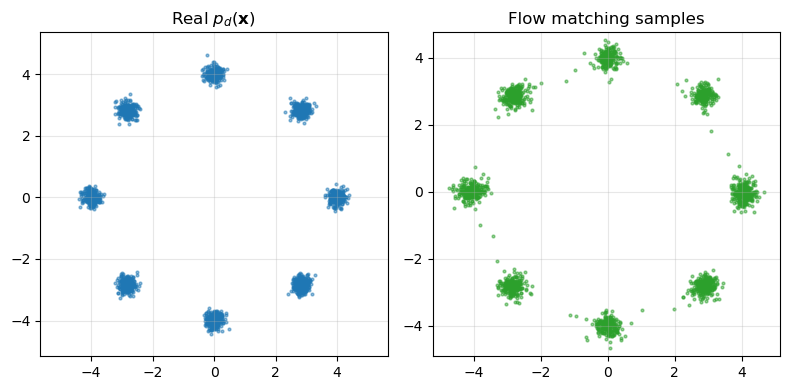

In [13]:
# Decode a batch of pure-noise samples through the trained flow.
flow_network.eval()
initial_noise = torch.randn(2_000, 2, device=DEVICE)
flow_generated = flow_network.decode(initial_noise, num_steps=100).cpu()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(real_samples[:, 0], real_samples[:, 1], s=4, alpha=0.5)
axes[0].set_title("Real $p_d(\\mathbf{x})$"); axes[0].axis("equal"); axes[0].grid(alpha=0.3)
axes[1].scatter(flow_generated[:, 0], flow_generated[:, 1], s=4, alpha=0.5, color="C2")
axes[1].set_title("Flow matching samples"); axes[1].axis("equal"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## B.4 Visualising the learned flow

Because the flow is deterministic, we can plot the trajectories of a small number of seed points as they are pushed from noise to data.

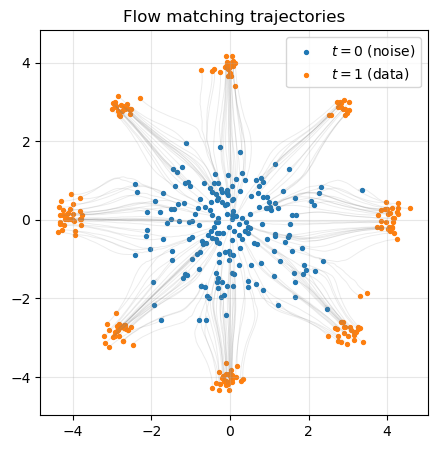

In [14]:
@torch.no_grad()
def collect_trajectories(
    velocity_field: ConditionalVelocityField,
    initial_state: Tensor,
    num_steps: int = 50,
) -> Tensor:
    """Run RK4 from t=0 to t=1, returning the state at every step.

    Returns:
        Tensor of shape (num_steps + 1, num_points, data_dim).
    """
    device = initial_state.device
    dtype = initial_state.dtype
    t = torch.tensor(0.0, device=device, dtype=dtype)
    dt = torch.tensor(1.0 / num_steps, device=device, dtype=dtype)

    def velocity_at(state: Tensor, t_scalar: Tensor) -> Tensor:
        return velocity_field(state, t_scalar.expand(state.shape[0]))

    states = [initial_state.clone()]
    state = initial_state
    for _ in range(num_steps):
        state = runge_kutta_4_step(velocity_at, state, t, dt)
        states.append(state.clone())
        t = t + dt
    return torch.stack(states, dim=0)


seed_noise = torch.randn(200, 2, device=DEVICE)
trajectories = collect_trajectories(flow_network, seed_noise, num_steps=50).cpu()

plt.figure(figsize=(5, 5))
# Light grey: trajectories.
for i in range(trajectories.shape[1]):
    plt.plot(trajectories[:, i, 0], trajectories[:, i, 1], color="grey", alpha=0.15, linewidth=0.7)
# Blue: starting noise.
plt.scatter(trajectories[0, :, 0], trajectories[0, :, 1], s=8, color="C0", label="$t=0$ (noise)")
# Orange: final samples.
plt.scatter(trajectories[-1, :, 0], trajectories[-1, :, 1], s=8, color="C1", label="$t=1$ (data)")
plt.legend(); plt.axis("equal"); plt.grid(alpha=0.3)
plt.title("Flow matching trajectories"); plt.show()


---

## C. Summary

| Aspect | Diffusion | Flow matching |
|---|---|---|
| Forward process | $\mathbf{z}_t = \alpha_t \mathbf{x} + \sigma_t \boldsymbol{\varepsilon}$ | linear interpolant $\boldsymbol{\psi}_t$ |
| Network predicts | noise $\hat{\boldsymbol{\varepsilon}}_\theta$ or velocity $\hat{\mathbf{v}}_\theta$ | velocity $\hat{\mathbf{v}}_\theta$ |
| Inference | ancestral Gaussian sampling | ODE solve |
| Stochastic? | Yes (noise injected each step) | No (deterministic ODE) |
| Code complexity | medium (custom sampler) | small (any ODE solver) |

Both approaches share the same neural network and the same forward-noising idea — the difference is whether you model the *score* and use a stochastic reverse process, or model the *velocity* and use a deterministic ODE. As the tutorial notes (Section "Relation between the score and velocity field"), the two are connected by

$$\mathbf{s}_\theta(\mathbf{z}, t) = \frac{1}{\sigma_t} \cdot \frac{\alpha_t \mathbf{v}_\theta(\mathbf{z}, t) - \dot{\alpha}_t \mathbf{z}}{\dot{\alpha}_t \sigma_t - \alpha_t \dot{\sigma}_t},$$

so you can train either loss and use either sampler.

### Where to go next

- Replace `ScoreMLP` with a U-Net or transformer and train on MNIST or CIFAR.
- Add **classifier-free guidance** by training with random condition dropout and combining conditional/unconditional predictions at sample time.
- Plug a real ODE solver (`torchdiffeq.odeint`, `zuko`) for higher-quality flow matching samples.
- Try the **shifted cosine** schedule (`CosineNoiseSchedule(shift=2*log(noise_d/image_d))`) when scaling to high resolution images.
